<img src="https://github.com/KartikNW/MSDS_458_Public/blob/main/images2/NorthwesternHeader.png?raw=1" />

In [1]:
NOTEBOOK_VERSION = "3.0"
QUARTER = "Spring 2026"

from datetime import datetime
NOTEBOOK_START_TIME = datetime.now()
print(f"Notebook Version: {NOTEBOOK_VERSION} | {QUARTER}")

Notebook Version: 3.0 | Spring 2026


# Assignment 02 – Part 1: CNN Image Classification

In this assignment, we build and train a **Convolutional Neural Network (CNN)** to classify images from the **CIFAR-10 dataset**, which contains 60,000 32×32 color images across 10 categories (airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks).

The notebook walks through the **end-to-end image classification workflow**, including:

- Loading and exploring the CIFAR-10 dataset to understand its structure and class distribution
- Preprocessing images by normalizing pixel values and creating train/validation/test splits
- Building a **CNN architecture** with convolutional, pooling, dropout, and dense layers
- Training with **early stopping** and **model checkpointing** to prevent overfitting
- Evaluating performance using **accuracy**, **confusion matrices**, and **classification reports**
- Visualizing **feature maps** to understand what the CNN learns at each convolutional layer

By the end of this assignment, you will have hands-on experience building a CNN from scratch and interpreting its behavior on a real-world image classification task.

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

- Load and preprocess image data for deep learning
- Build a **multi-layer CNN** using Keras `Sequential` API
- Train a CNN with **callbacks** (early stopping, model checkpointing)
- Evaluate classification performance using **accuracy**, **confusion matrices**, and **per-class metrics**
- Visualize **convolutional feature maps** to interpret what the network learns
- Understand the roles of **Conv2D**, **MaxPooling**, **Dropout**, and **BatchNormalization** layers

## Notebook Overview

1. 🧩 Step 1: Setup and Imports
2. ✅ Step 2: Version Requirements
3. 🛠️ Step 3: Define Helper Functions
4. 🗂️ Step 4: Load the CIFAR-10 Dataset
5. 🔍 Step 5: Exploratory Data Analysis (EDA)
6. 🔧 Step 6: Data Preprocessing
7. 🏗️ Step 7: Build CNN Model
8. ⚙️ Step 8: Compile the Model
9. 🚂 Step 9: Train the Model
10. 📊 Step 10: Evaluate the Model
11. 🔄 Step 11: Load Saved Model and Predict
12. 🔬 Step 12: Visualize Feature Maps
13. 🎓 Summary

## 🧩 Step 1: Setup and Imports

Import all necessary libraries for data handling, visualization, and building the CNN model.

In [2]:
import numpy as np
import pandas as pd
from packaging import version

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as k

In [3]:
%matplotlib inline
np.set_printoptions(precision=3, suppress=True)

## ✅ Step 2: Version Requirements

This assignment requires recent versions of **Python** and **TensorFlow/Keras** to ensure compatibility with the CNN code.

| Library | Minimum Version | Purpose |
|---------|----------------|---------|
| Python | 3.9+ | Core language |
| TensorFlow | 2.0+ | Deep learning framework |
| scikit-learn | 1.0+ | Metrics and train/test split |
| NumPy | 1.21+ | Numerical operations |
| Matplotlib | 3.5+ | Visualization |
| Seaborn | 0.11+ | Statistical visualization |

In [4]:
print("This notebook requires TensorFlow 2.0 or above")
print("TensorFlow version: ", tf.__version__)
assert version.parse(tf.__version__).release[0] >=2

This notebook requires TensorFlow 2.0 or above
TensorFlow version:  2.19.0


## 🛠️ Step 3: Define Helper Functions

These utility functions handle exploratory data analysis, training curve visualization, classification reporting, and confusion matrix plotting.
They are defined here so they can be called later in the notebook.

In [5]:
def get_three_classes(x, y):
    def indices_of(class_id):
        indices, _ = np.where(y == float(class_id))
        return indices

    indices = np.concatenate([indices_of(0), indices_of(1), indices_of(2)], axis=0)

    x = x[indices]
    y = y[indices]

    count = x.shape[0]
    indices = np.random.choice(range(count), count, replace=False)

    x = x[indices]
    y = y[indices]

    y = tf.keras.utils.to_categorical(y)

    return x, y

In [6]:
def show_random_examples(x, y, p):
    indices = np.random.choice(range(x.shape[0]), 10, replace=False)

    x = x[indices]
    y = y[indices]
    p = p[indices]

    plt.figure(figsize=(10, 5))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x[i])
        plt.xticks([])
        plt.yticks([])
        col = 'green' if np.argmax(y[i]) == np.argmax(p[i]) else 'red'
        plt.xlabel(class_names_preview[np.argmax(p[i])], color=col)
    plt.show()

In [7]:
def plot_history(history):
  losses = history.history['loss']
  accs = history.history['accuracy']
  val_losses = history.history['val_loss']
  val_accs = history.history['val_accuracy']
  epochs = len(losses)

  plt.figure(figsize=(16, 4))
  for i, metrics in enumerate(zip([losses, accs], [val_losses, val_accs], ['Loss', 'Accuracy'])):
    plt.subplot(1, 2, i + 1)
    plt.plot(range(epochs), metrics[0], label='Training {}'.format(metrics[2]))
    plt.plot(range(epochs), metrics[1], label='Validation {}'.format(metrics[2]))
    plt.legend()
  plt.show()

def display_training_curves(training, validation, title, subplot):
  ax = plt.subplot(subplot)
  ax.plot(training)
  ax.plot(validation)
  ax.set_title('model '+ title)
  ax.set_ylabel(title)
  ax.set_xlabel('epoch')
  ax.legend(['training', 'validation'])

In [8]:
def print_validation_report(y_test, predictions):
    print("Classification Report")
    print(classification_report(y_test, predictions))
    print('Accuracy Score: {}'.format(accuracy_score(y_test, predictions)))
    print('Root Mean Square Error: {}'.format(np.sqrt(MSE(y_test, predictions))))

In [9]:
def plot_confusion_matrix(y_true, y_pred):
    mtx = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(16,12))
    sns.heatmap(mtx, annot=True, fmt='d', linewidths=.75,  cbar=False, ax=ax,cmap='Blues',linecolor='white')
    #  square=True,
    plt.ylabel('true label')
    plt.xlabel('predicted label')

## 🗂️ Step 4: Load the CIFAR-10 Dataset

The CIFAR-10 dataset consists of 60,000 32×32 colour images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

The dataset is divided into five training batches and one test batch, each with 10,000 images. The test batch contains exactly 1,000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 5,000 images from each class.

> 📖 **Reference**: [The CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html)

In [10]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


* Tuple of Numpy arrays: (x_train, y_train), (x_test, y_test).
* x_train, x_test: uint8 arrays of color image data with shapes (num_samples, 32, 32).
* y_train, y_test: uint8 arrays of digit labels (integers in range 0-9)

## 🔍 Step 5: Exploratory Data Analysis (EDA)

Examine the shapes and structure of the training and test datasets, review class labels, and visualize sample images.

In [11]:
print('train_images:\t{}'.format(x_train.shape))
print('train_labels:\t{}'.format(y_train.shape))
print('test_images:\t\t{}'.format(x_test.shape))
print('test_labels:\t\t{}'.format(y_test.shape))

train_images:	(50000, 32, 32, 3)
train_labels:	(50000, 1)
test_images:		(10000, 32, 32, 3)
test_labels:		(10000, 1)


### Review Labels

In [12]:
print("First ten labels training dataset:\n {}\n".format(y_train[0:10]))
print("This output the numeric label, need to convert to item description")

First ten labels training dataset:
 [[6]
 [9]
 [9]
 [4]
 [1]
 [1]
 [2]
 [7]
 [8]
 [3]]

This output the numeric label, need to convert to item description


### Plot Subset of Examples

In [13]:
(train_images, train_labels),(test_images, test_labels)= tf.keras.datasets.cifar10.load_data()

In [14]:
x_preview, y_preview = get_three_classes(train_images, train_labels)
x_preview, y_preview = get_three_classes(test_images, test_labels)

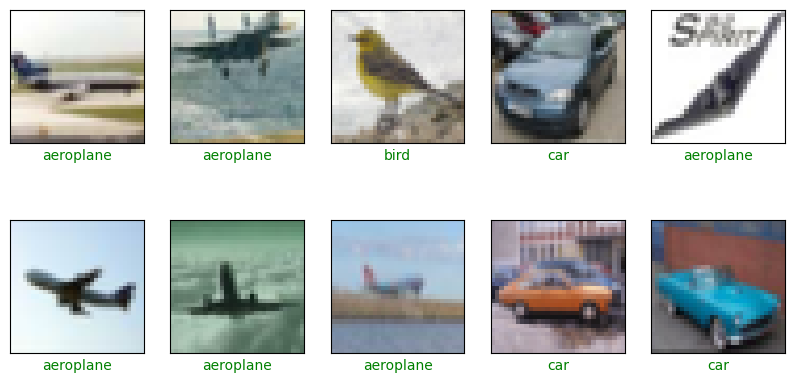

In [15]:
class_names_preview = ['aeroplane', 'car', 'bird']

show_random_examples(x_preview, y_preview, y_preview)

### 💡 Suggestions for Further Exploration
- Visualize more than 3 classes or display a full grid of all 10 classes
- Plot the **class distribution** to verify balance across training and test sets
- Compute **per-channel (RGB) mean and standard deviation** across the training set
- Display images that are commonly misclassified (after training) to spot patterns

## 🔧 Step 6: Data Preprocessing

Prepare the data for model training by defining class labels, creating a validation split, and normalizing pixel values to the [0, 1] range.

The labels are an array of integers, ranging from 0 to 9. These correspond to the class of clothing the image represents:

|Label  |Class_  |
|-------|--------|
|0|	airplane     |
|1|	automobile   |
|2|	bird         |
|3|	cat          |
|4|	deer         |
|5|	dog          |
|6|	frog         |
|7|	horse        |
|8|	ship         |
|9|	truck        |

In [16]:
class_names = ['airplane'
,'automobile'
,'bird'
,'cat'
,'deer'
,'dog'
,'frog'
,'horse'
,'ship'
,'truck']

### Create Validation Data Set

In [17]:
x_train_split, x_valid_split, y_train_split, y_valid_split = train_test_split(x_train
                                                                              ,y_train
                                                                              ,test_size=.1
                                                                              ,random_state=42
                                                                              ,shuffle=True)

### Confirm Datasets {Train, Validation, Test}

In [18]:
print(x_train_split.shape, x_valid_split.shape, x_test.shape)

(45000, 32, 32, 3) (5000, 32, 32, 3) (10000, 32, 32, 3)


### Rescale Examples {Train, Validation, Test}

The images are 32×32 NumPy arrays, with pixel values ranging from 0 to 255.

1. Each element in each example is a pixel value
2. Pixel values range from 0 to 255
3. 0 = black
4. 255 = white

In [19]:
x_train_norm = x_train_split/255
x_valid_norm = x_valid_split/255
x_test_norm = x_test/255

## 🏗️ Step 7: Build CNN Model

<img src="https://github.com/KartikNW/MSDS_458_Public/blob/main/images2/CNN_architecture_v4.png?raw=1" width="800">

We use a `Sequential` class defined in Keras to create our model. The first 9 layers (Conv2D, MaxPooling, Dropout) handle **feature learning**. The last 3 layers handle **classification**.

In [20]:
# ======================================================================
# CNN Architecture — EXPERIMENT HERE: try different filters, units, dropout
# ======================================================================
k.clear_session()
model = Sequential([
  Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu,input_shape=x_train_norm.shape[1:]),  # --- EXPERIMENT HERE: try 64, 128, 256 filters ---
  MaxPool2D((2, 2),strides=2),
  Dropout(0.3),  # --- EXPERIMENT HERE: try 0.2, 0.3, 0.5 ---
  Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu),  # --- EXPERIMENT HERE: try different filter counts ---
  MaxPool2D((2, 2),strides=2),
  Dropout(0.3),
  Conv2D(filters=512, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu),  # --- EXPERIMENT HERE: try different filter counts ---
  MaxPool2D((2, 2),strides=2),
  Dropout(0.3),
  Flatten(),
  Dense(units=384,activation=tf.nn.softmax,kernel_regularizer=tf.keras.regularizers.L2(0.001)),  # --- EXPERIMENT HERE: try 128, 256, 512 units ---
  BatchNormalization(),
  Dropout(0.3),
  Dense(units=10, activation=tf.nn.softmax)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 384)            │       786,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 384)            │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         3,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,271,114 (8.66 MB)

 Trainable params: 2,270,346 (8.66 MB)

 Non-trainable params: 768 (3.00 KB)

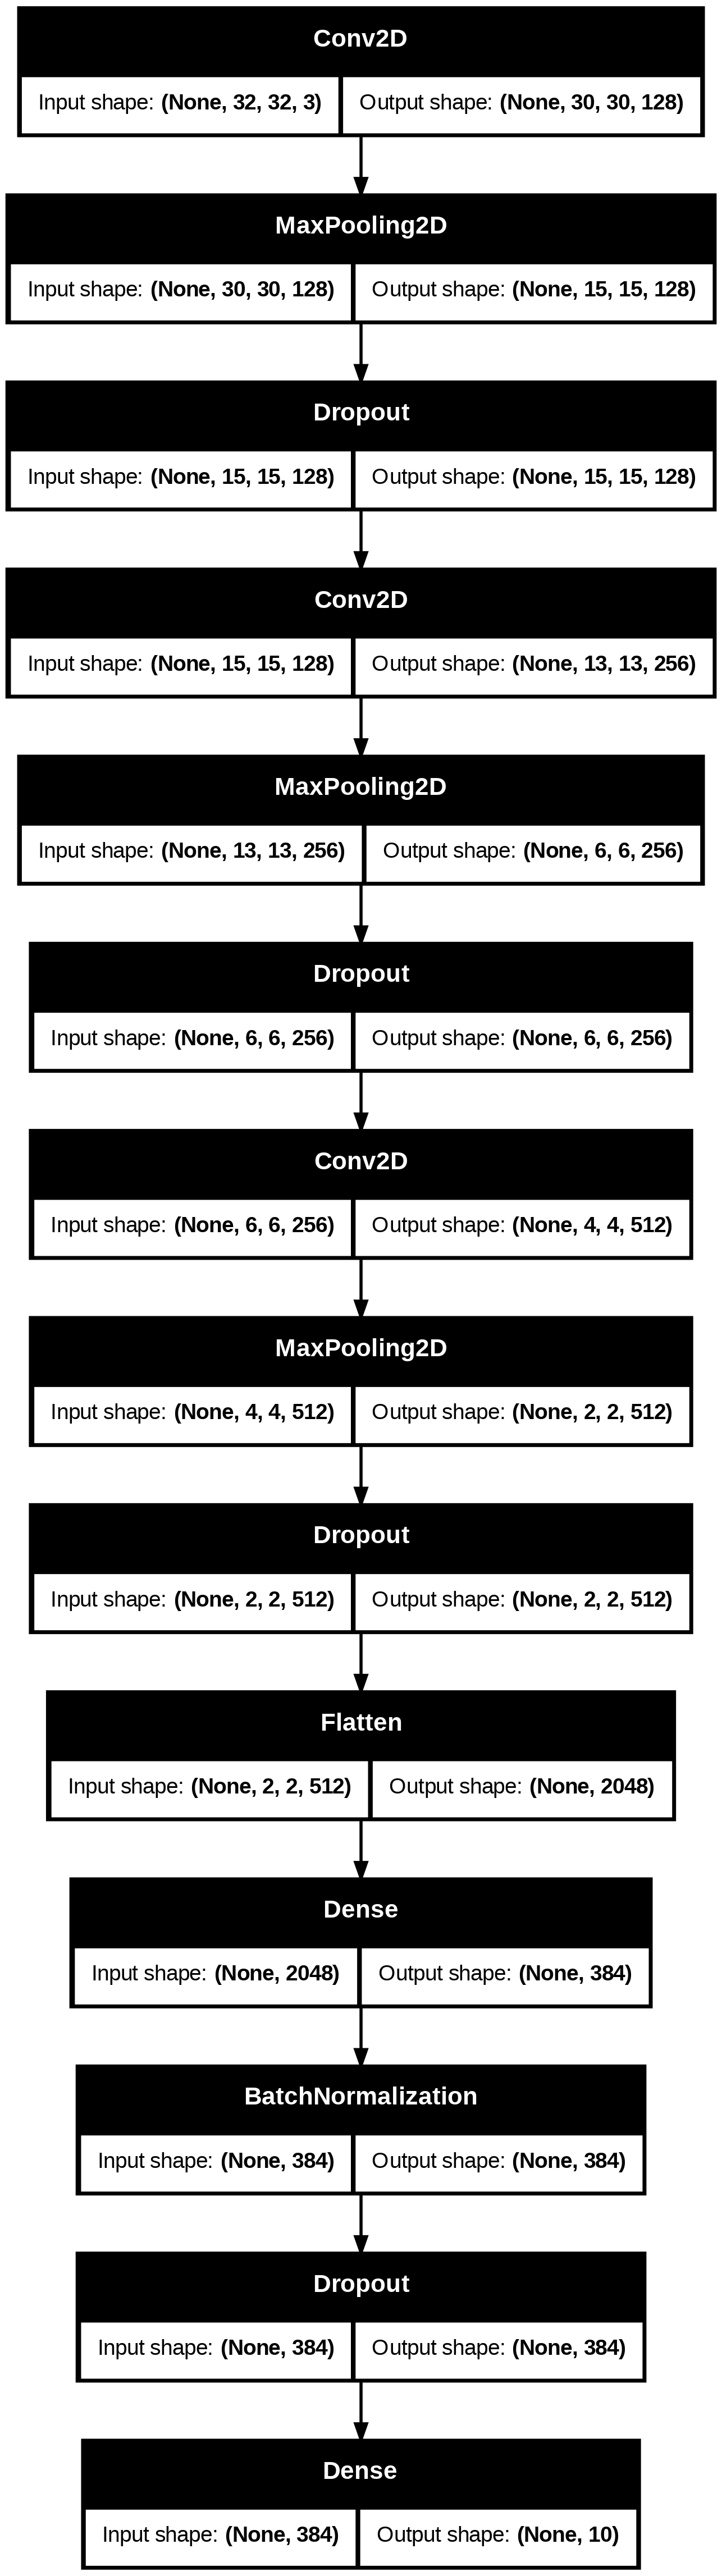

In [22]:
tf.keras.utils.plot_model(model, "CIFAR10.png", show_shapes=True)

### 💡 Suggestions for Further Exploration
- Add more **convolutional blocks** (Conv2D → MaxPool → Dropout) to deepen the network
- Try **different activation functions** (e.g., `LeakyReLU`, `ELU`) instead of ReLU
- Experiment with **kernel sizes** (e.g., 5×5 vs 3×3) and observe the effect on accuracy
- Add **data augmentation** (rotations, flips, shifts) using `tf.keras.preprocessing.image.ImageDataGenerator`
- Compare **with and without BatchNormalization** to see its impact on training stability

## ⚙️ Step 8: Compile the Model

In addition to setting up our model architecture, we also need to define which algorithm should the model use in order to optimize the weights and biases as per the given data. We will use stochastic gradient descent.

We also need to define a loss function. Think of this function as the difference between the predicted outputs and the actual outputs given in the dataset. This loss needs to be minimised in order to have a higher model accuracy. That's what the optimization algorithm essentially does - it minimises the loss during model training. For our multi-class classification problem, categorical cross entropy is commonly used.

Finally, we will use the accuracy during training as a metric to keep track of as the model trains.

> 📖 **Reference**: [tf.keras.losses.SparseCategoricalCrossentropy](https://www.tensorflow.org/api_docs/python/tf/keras/losses/SparseCategoricalCrossentropy)

In [23]:
# --- EXPERIMENT HERE: try different optimizers (e.g. 'sgd', 'rmsprop', 'adam') ---
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

## 🚂 Step 9: Train the Model

Train the CNN using the normalized training data with **early stopping** and **model checkpointing**.

> 📖 **References**:
> - [tf.keras.callbacks.EarlyStopping](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping)
> - [tf.keras.callbacks.ModelCheckpoint](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint)

In [24]:
# --- EXPERIMENT HERE: try different epochs, batch_size, patience ---
history = model.fit(x_train_norm
                    ,y_train_split
                    ,epochs=200
                    ,batch_size=64
                    ,validation_data=(x_valid_norm, y_valid_split)
                    ,callbacks=[
                     tf.keras.callbacks.ModelCheckpoint("CNN_model.keras",save_best_only=True,save_weights_only=False)
                     ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3),
                    ]
                   )

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.4189 - loss: 1.6676 - val_accuracy: 0.5406 - val_loss: 1.3774
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5592 - loss: 1.3184 - val_accuracy: 0.5990 - val_loss: 1.2066
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6176 - loss: 1.1776 - val_accuracy: 0.6374 - val_loss: 1.0877
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6583 - loss: 1.0787 - val_accuracy: 0.6594 - val_loss: 1.0693
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6833 - loss: 1.0161 - val_accuracy: 0.6876 - val_loss: 0.9871
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7046 - loss: 0.9546 - val_accuracy: 0.7226 - val_loss: 0.8829
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7187 - loss: 0.9228 - val_accuracy: 0.7116 - val_loss: 0.9040
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7339 - loss: 0.8743 

## 📊 Step 10: Evaluate the Model

In order to ensure that this is not a simple "memorization" by the machine, we should evaluate the performance on the test set. This is easy to do, we simply use the `evaluate` method on our model.

In [25]:
model = tf.keras.models.load_model("CNN_model.keras", custom_objects={'softmax_v2': tf.keras.activations.softmax})
print(f"Test acc: {model.evaluate(x_test_norm, y_test)[1]:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7739 - loss: 0.7696
Test acc: 0.774


### Predictions

In [26]:
preds = model.predict(x_test_norm)
print('shape of preds: ', preds.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
shape of preds:  (10000, 10)


### Plotting Performance Metrics

We use Matplotlib to create 2 plots--displaying the training and validation loss (resp. accuracy) for each (training) epoch side by side.

In [27]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [28]:
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
10,0.761,0.798,0.770,0.773
11,0.767,0.781,0.780,0.742
12,0.774,0.762,0.761,0.798
13,0.778,0.749,0.762,0.794
14,0.788,0.718,0.771,0.767


### Plot Training Metrics (Loss and Accuracy)

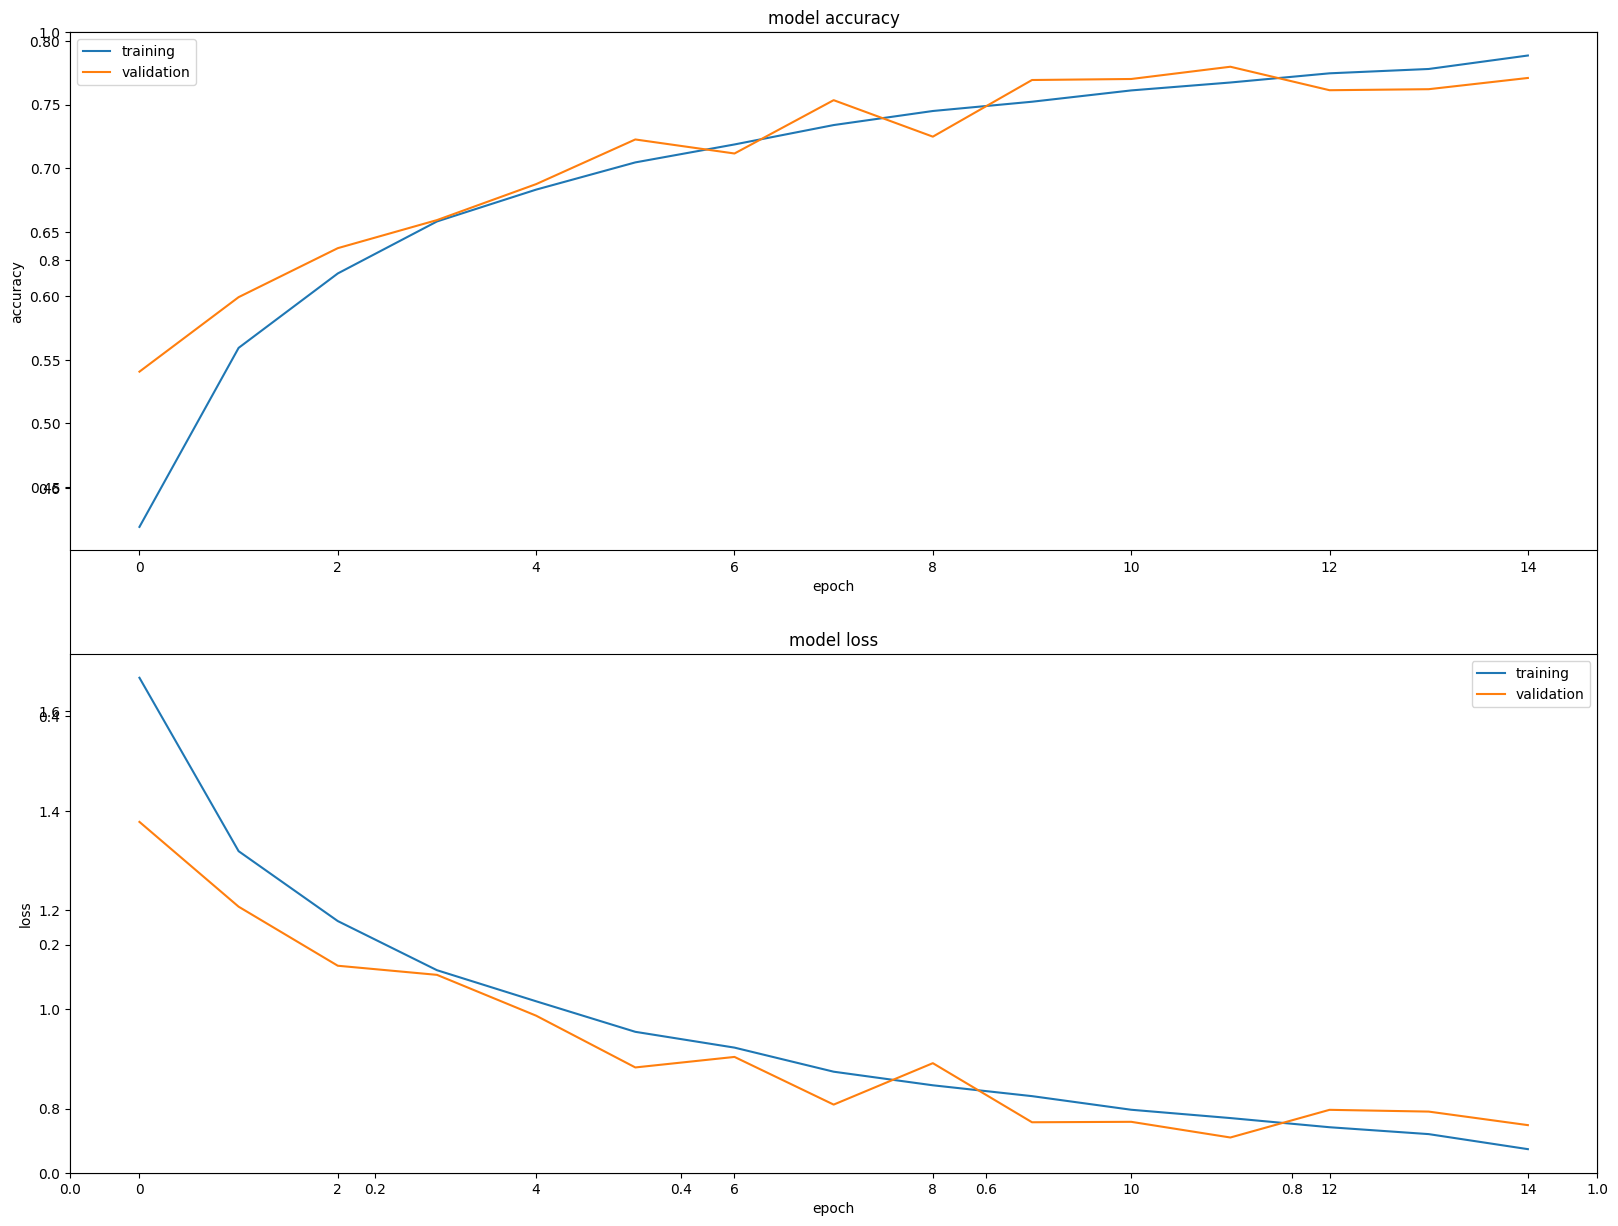

In [29]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

### Confusion Matrix

Using `sklearn.metrics`. Then we visualize the confusion matrix and see what that tells us.

In [30]:
pred1= model.predict(x_test_norm)
pred1=np.argmax(pred1, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [31]:
print_validation_report(y_test, pred1)

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1000
           1       0.91      0.89      0.90      1000
           2       0.70      0.68      0.69      1000
           3       0.60      0.64      0.62      1000
           4       0.66      0.77      0.71      1000
           5       0.80      0.57      0.67      1000
           6       0.73      0.89      0.80      1000
           7       0.86      0.76      0.81      1000
           8       0.83      0.90      0.87      1000
           9       0.88      0.83      0.85      1000

    accuracy                           0.77     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.78      0.77      0.77     10000

Accuracy Score: 0.7739
Root Mean Square Error: 1.8932775813387746


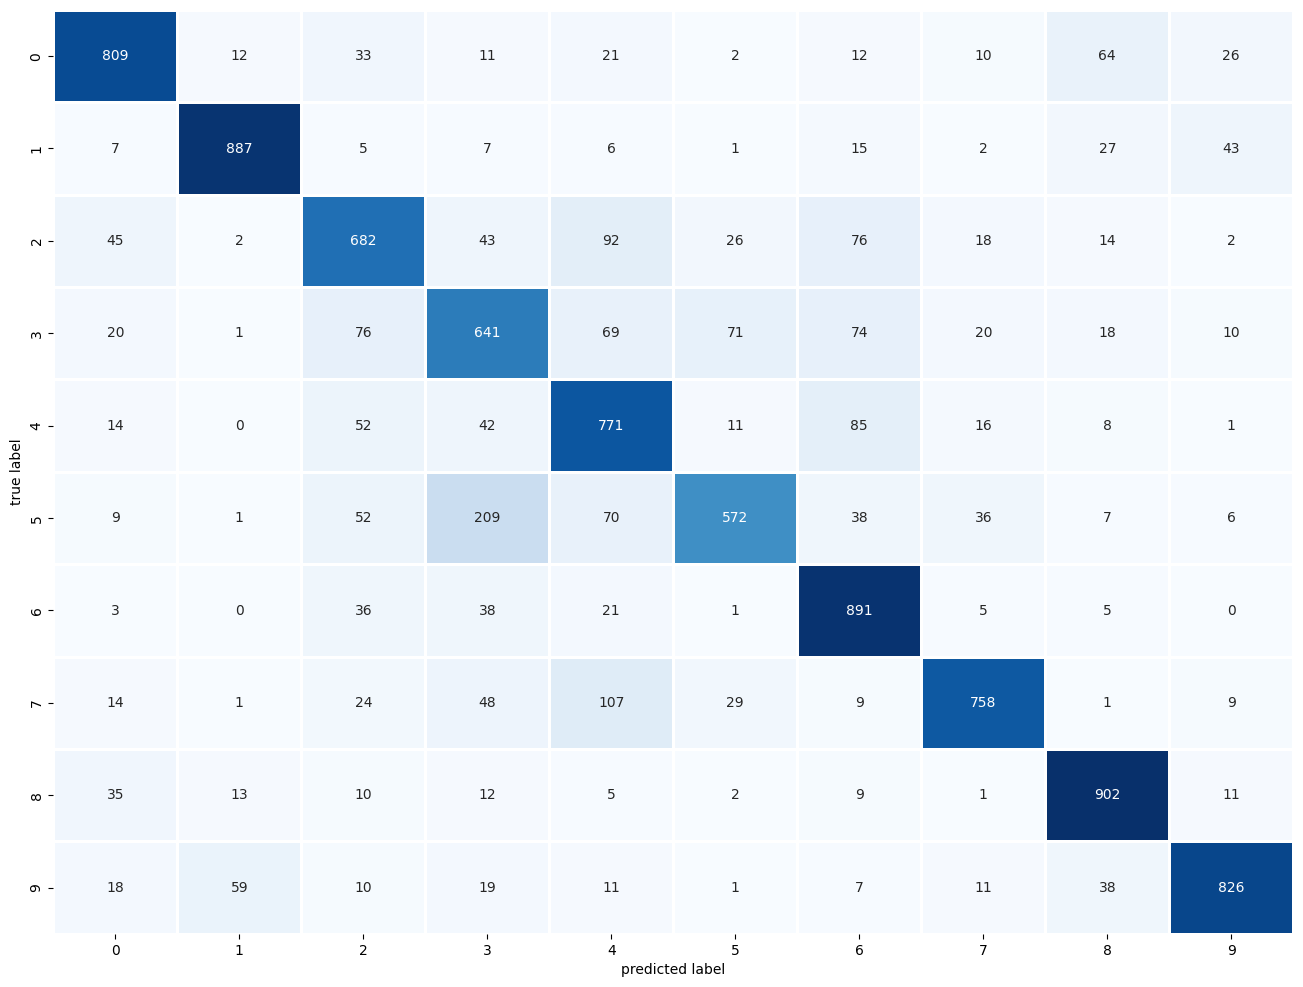

In [32]:
plot_confusion_matrix(y_test,pred1)

### 💡 Suggestions for Further Exploration
- Analyze which **class pairs** are most commonly confused and hypothesize why
- Plot **per-class accuracy** as a bar chart to identify weak categories
- Experiment with **learning rate schedules** (e.g., `ReduceLROnPlateau`) to improve convergence
- Try **different loss functions** (e.g., `CategoricalCrossentropy` with one-hot labels)

## 🔄 Step 11: Load Saved Model and Predict

Reload the best saved model from the checkpoint and generate class probability predictions.

> 📖 **Reference**: [tf.keras.models.load_model](https://www.tensorflow.org/api_docs/python/tf/keras/models/load_model)

In [33]:
model = tf.keras.models.load_model("CNN_model.keras", custom_objects={'softmax_v2': tf.keras.activations.softmax})

In [34]:
preds = model.predict(x_test_norm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [35]:
preds.shape

(10000, 10)

### Prediction Probabilities Table

In [36]:
cm = sns.light_palette((260, 75, 60), input="husl", as_cmap=True)

In [37]:
df = pd.DataFrame(preds[0:20], columns = ['airplane'
                                          ,'automobile'
                                          ,'bird'
                                          ,'cat'
                                          ,'deer'
                                          ,'dog'
                                          ,'frog'
                                          ,'horse'
                                          ,'ship'
                                          ,'truck'])
df.style.format("{:.2%}").background_gradient(cmap=cm)

,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
0,0.13%,0.03%,0.76%,84.13%,0.21%,10.76%,3.49%,0.30%,0.13%,0.07%
1,1.08%,3.89%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,94.93%,0.08%
2,1.79%,3.00%,0.04%,0.11%,0.05%,0.02%,0.06%,0.02%,93.51%,1.40%
3,71.30%,0.05%,2.93%,0.08%,1.09%,0.00%,0.01%,0.01%,24.51%,0.02%
4,0.01%,0.00%,1.07%,0.36%,2.35%,0.04%,96.16%,0.00%,0.01%,0.00%
5,0.00%,0.00%,0.01%,0.37%,0.02%,0.12%,99.46%,0.00%,0.00%,0.00%
6,0.02%,64.99%,0.00%,0.01%,0.00%,0.00%,0.00%,0.01%,0.01%,34.95%
7,1.83%,0.04%,14.12%,2.97%,3.18%,0.41%,76.79%,0.09%,0.48%,0.09%
8,0.09%,0.01%,4.03%,86.83%,2.53%,2.28%,3.91%,0.28%,0.03%,0.02%
9,0.51%,75.98%,0.12%,0.03%,0.05%,0.02%,0.13%,0.04%,0.27%,22.84%


## 🔬 Step 12: Visualize Feature Maps

Extract and visualize the **convolutional feature maps** to understand what patterns the CNN detects at each layer.
This is a powerful interpretability technique that shows how the network progressively extracts higher-level features from raw pixel data.

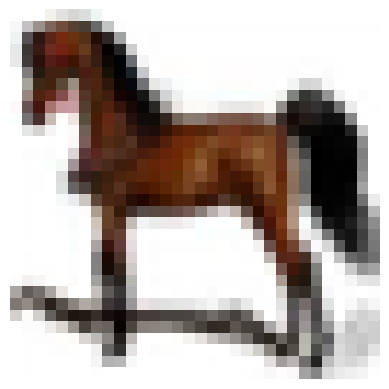

In [38]:
(_,_), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

img = test_images[2004]
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)

class_names = ['airplane'
,'automobile'
,'bird'
,'cat'
,'deer'
,'dog'
,'frog'
,'horse'
,'ship'
,'truck']

plt.imshow(img, cmap='viridis')
plt.axis('off')
plt.show()

In [39]:
# Extracts the outputs of the top 8 layers:
layer_outputs = [layer.output for layer in model.layers[:8]]
# Creates a model that will return these outputs, given the model input:
activation_model = models.Model(inputs=model.inputs, outputs=layer_outputs)

In [40]:
activations = activation_model.predict(img_tensor)
len(activations)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 884ms/step


8

In [41]:
layer_names = []
for layer in model.layers:
    layer_names.append(layer.name)

layer_names

['conv2d',
 'max_pooling2d',
 'dropout',
 'conv2d_1',
 'max_pooling2d_1',
 'dropout_1',
 'conv2d_2',
 'max_pooling2d_2',
 'dropout_2',
 'flatten',
 'dense',
 'batch_normalization',
 'dropout_3',
 'dense_1']

/tmp/ipykernel_1919/4183080112.py:28: RuntimeWarning: invalid value encountered in divide
  channel_image /= channel_image.std()
/tmp/ipykernel_1919/4183080112.py:31: RuntimeWarning: invalid value encountered in cast
  channel_image = np.clip(channel_image, 0, 255).astype('uint8')


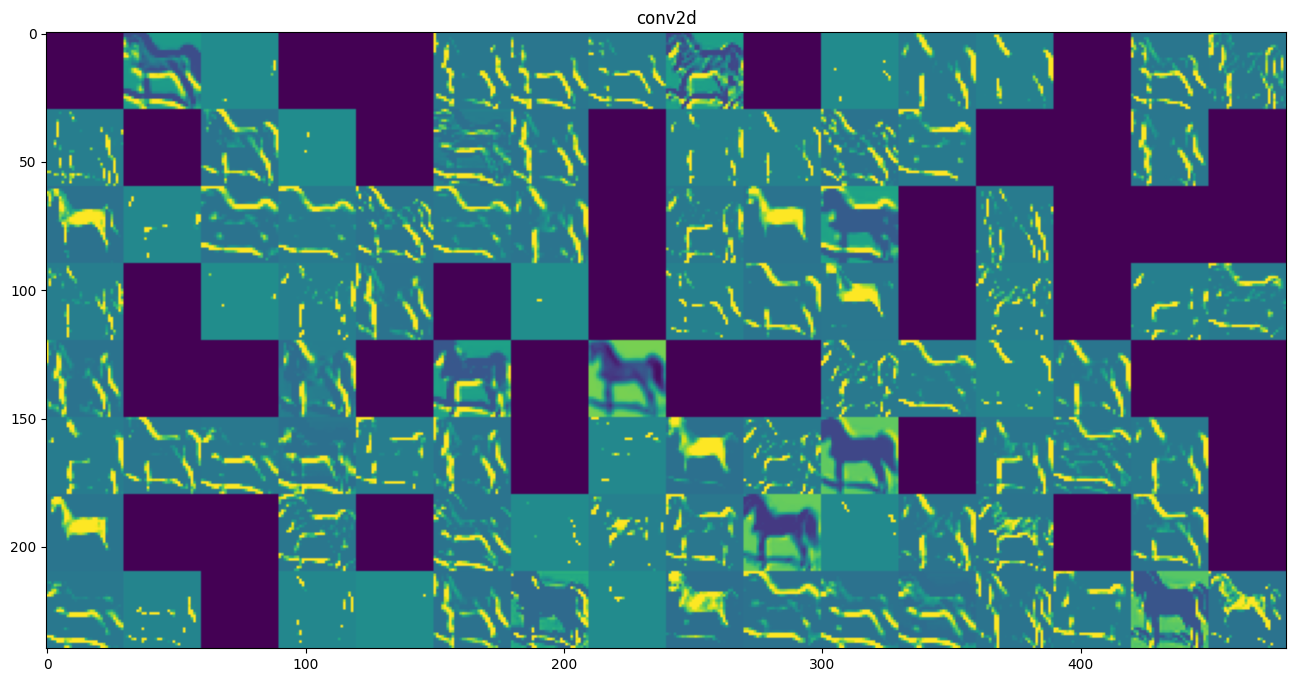

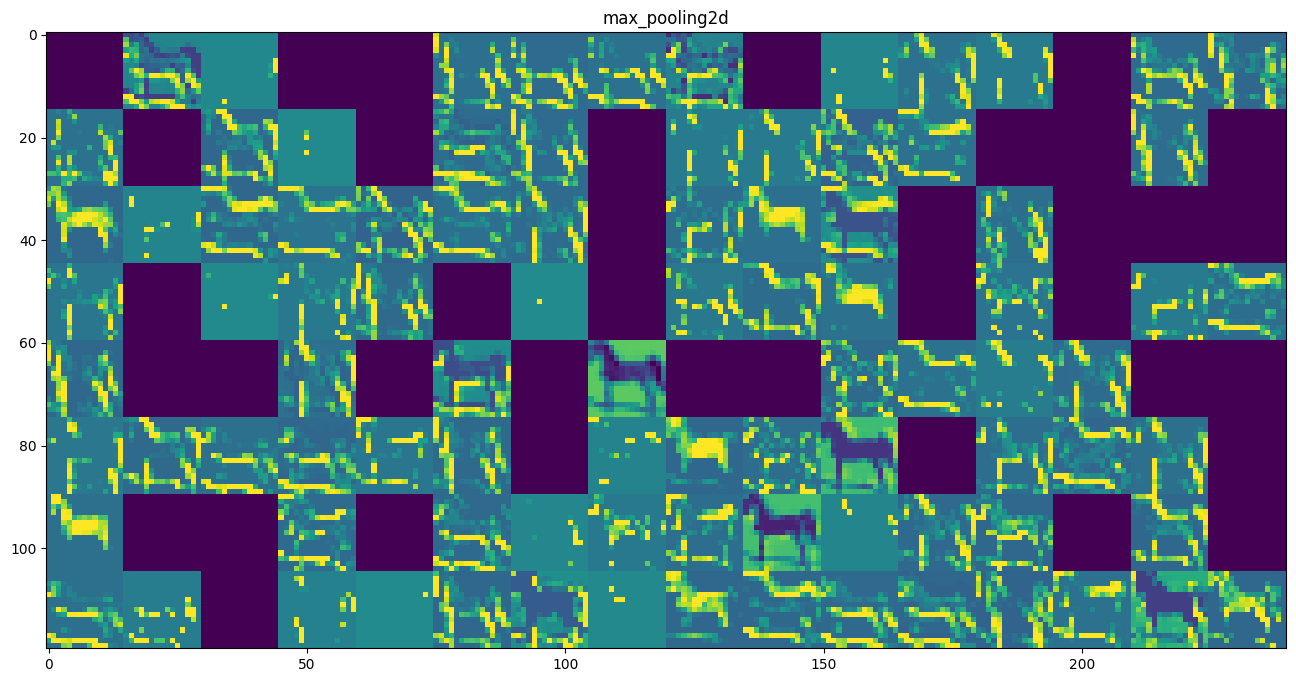

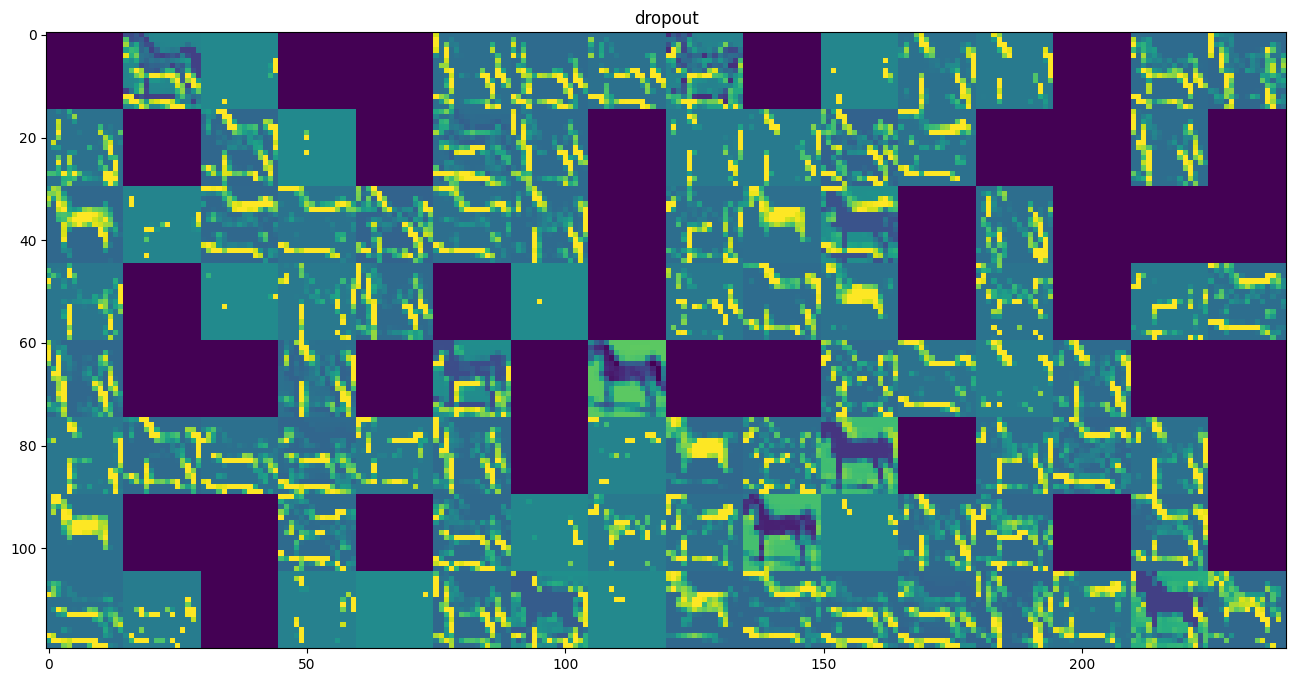

In [42]:
# These are the names of the layers, so can have them as part of our plot
layer_names = []
for layer in model.layers[:3]:
    layer_names.append(layer.name)

images_per_row = 16

# Now let's display our feature maps
for layer_name, layer_activation in zip(layer_names, activations):
    # This is the number of features in the feature map
    n_features = layer_activation.shape[-1]

    # The feature map has shape (1, size, size, n_features)
    size = layer_activation.shape[1]

    # We will tile the activation channels in this matrix
    n_cols = n_features // images_per_row
    display_grid = np.zeros((size * n_cols, images_per_row * size))

    # We'll tile each filter into this big horizontal grid
    for col in range(n_cols):
        for row in range(images_per_row):
            channel_image = layer_activation[0,
                                             :, :,
                                             col * images_per_row + row]
            # Post-process the feature to make it visually palatable
            channel_image -= channel_image.mean()
            channel_image /= channel_image.std()
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grid[col * size : (col + 1) * size,
                         row * size : (row + 1) * size] = channel_image

    # Display the grid
    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1],
                        scale * display_grid.shape[0]))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

plt.show();

### 💡 Suggestions for Further Exploration
- Visualize feature maps from **deeper layers** (not just the first 3) to see higher-level abstractions
- Use **Grad-CAM** to create attention heatmaps that highlight which regions of the image influenced the prediction most
- Compare feature maps for **correctly vs. incorrectly classified** images
- Try visualizing the **learned filters** (weights) directly, rather than the activations

## 🎓 Summary

In this notebook, you:

1. Loaded and explored the **CIFAR-10** image classification dataset
2. Preprocessed images by normalizing pixel values and splitting into train/validation/test sets
3. Built a **CNN** with three convolutional blocks (Conv2D → MaxPool → Dropout) and fully connected layers
4. Trained the model with **early stopping** and **model checkpointing**
5. Evaluated performance using **accuracy**, **confusion matrices**, and **classification reports**
6. Visualized **convolutional feature maps** to understand what the network learns

**Next**: In Part 2, you will extract hidden layer activations and use **t-SNE** to visualize how the CNN represents images in its learned feature space.

In [43]:
NOTEBOOK_END_TIME = datetime.now()
elapsed = NOTEBOOK_END_TIME - NOTEBOOK_START_TIME
total_mins, total_secs = divmod(int(elapsed.total_seconds()), 60)
print(f"✅ Notebook complete | Version: {NOTEBOOK_VERSION} | {QUARTER}")
print(f"Total time:  {total_mins}m {total_secs}s")
print(f"Current time: {NOTEBOOK_END_TIME.strftime('%Y-%m-%d %H:%M:%S')}")

✅ Notebook complete | Version: 3.0 | Spring 2026
Total time:  3m 28s
Current time: 2026-03-18 03:58:39
